In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm


In [72]:
import numpy as np

def detect_period(arr, max_period=20, tol=1e-6):

    arr = np.array(arr, dtype=float)

    if not np.all(np.isfinite(arr)):
        return None

    arr = np.round(arr, int(-np.log10(tol)))

    n = len(arr)

    for p in range(1, min(max_period, n // 2) + 1):
        is_periodic = True
        for i in range(n - p):
            if arr[i] != arr[i + p]:
                is_periodic = False
                break
        if is_periodic:
            return p

    return None


In [82]:
detect_period([1, 1, 1, 12, 1 ,1])

C:\Users\topi7\AppData\Local\Temp\ipykernel_18564\2800936082.py:39: RuntimeWarning: overflow encountered in scalar multiply
  x_new = alpha_tilde * (1 - u1) * y * (1 - y)
C:\Users\topi7\AppData\Local\Temp\ipykernel_18564\2800936082.py:30: RuntimeWarning: overflow encountered in scalar multiply
  x_new = alpha_tilde * (1 - u1) * y * (1 - y)


[Text(1, 0, '1 период'),
 Text(1, 1, '2 период'),
 Text(1, 2, '>2 период'),
 Text(1, 3, 'не удалось посчитать')]

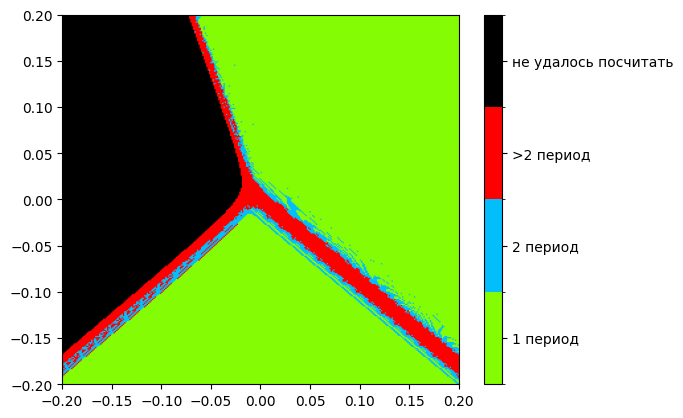

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Фиксированные параметры

u1 = 0.2
u2 = 0.1

# Диапазоны параметров
v_vals = np.linspace(-0.2, 0.2, 300)
mu2_vals = np.linspace(-0.2, 0.2, 300)

N_trans = 500   # число итераций
N_iter = 50     # - столько последних чисел сохраняем, чтобы понять структуру

# Начальные условия
x0, y0 = 0.1, 0.1

regime_map = np.full((len(mu2_vals), len(v_vals)), -1)

for i, mu2 in enumerate(mu2_vals):
    alpha_tilde = (1 + mu2) / ((1 - u1) * (1 - u2))

    for j, v in enumerate(v_vals):
        x, y = x0, y0

        try:
            # Прогрев
            for _ in range(N_trans):
                x_new = alpha_tilde * (1 - u1) * y * (1 - y)
                y_new = (x + v * y) * (1 - u2)
                x, y = x_new, y_new
                if not np.isfinite(x) or not np.isfinite(y):
                    raise OverflowError

            # Сохраняем последние значения y
            y_vals = []
            for _ in range(N_iter):
                x_new = alpha_tilde * (1 - u1) * y * (1 - y)
                y_new = (x + v * y) * (1 - u2)
                x, y = x_new, y_new
                if not np.isfinite(x) or not np.isfinite(y):
                    raise OverflowError
                y_vals.append(y)

            # Анализ режима
            y_vals = np.array(y_vals)
            unique_vals = np.unique(np.round(y_vals, 4))

            if len(unique_vals) == 1:
                regime_map[i, j] = 0   # устойчивая точка
            elif len(unique_vals) == 2:
                regime_map[i, j] = 1   # период-2
            else:
                regime_map[i, j] = 2   # сложный режим
        except OverflowError:
            regime_map[i, j] = 3  # не удалось посчитать. Либо nan либо inf → белый цвет


cmap = ListedColormap(['#84fc03', '#03befc', 'red', '#000000'])
bounds = [-0.5, 0.5, 1.5, 2.5, 3.5]  # границы для нормировки
norm = BoundaryNorm(bounds, cmap.N)

plt.imshow(
    regime_map,
    extent=[v_vals[0], v_vals[-1], mu2_vals[0], mu2_vals[-1]],
    origin='lower',
    aspect='auto',
    cmap=cmap,
    norm=norm
)

cbar = plt.colorbar(ticks=[0,1,2, 3])
cbar.ax.set_yticklabels(['1 период', '2 период', '>2 период', 'не удалось посчитать'])


C:\Users\topi7\AppData\Local\Temp\ipykernel_18564\2246850138.py:39: RuntimeWarning: overflow encountered in scalar multiply
  x_new = alpha_tilde * (1 - u1) * y * (1 - y)
C:\Users\topi7\AppData\Local\Temp\ipykernel_18564\2246850138.py:30: RuntimeWarning: overflow encountered in scalar multiply
  x_new = alpha_tilde * (1 - u1) * y * (1 - y)
C:\Users\topi7\OneDrive\Desktop\FEFU\.venv\lib\site-packages\numpy\core\fromnumeric.py:59: RuntimeWarning: overflow encountered in multiply
  return bound(*args, **kwds)


[Text(1, 0, '1 период'),
 Text(1, 1, '2 период'),
 Text(1, 2, '>2 период'),
 Text(1, 3, 'не удалось посчитать')]

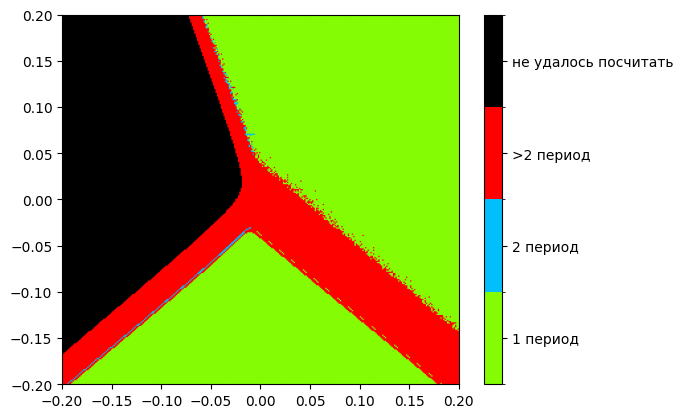

In [83]:
import numpy as np
import matplotlib.pyplot as plt

# Фиксированные параметры

u1 = 0.2
u2 = 0.1

# Диапазоны параметров
v_vals = np.linspace(-0.2, 0.2, 300)
mu2_vals = np.linspace(-0.2, 0.2, 300)

N_trans = 500   # число итераций
N_iter = 50     # - столько последних чисел сохраняем, чтобы понять структуру

# Начальные условия
x0, y0 = 0.1, 0.1

regime_map = np.full((len(mu2_vals), len(v_vals)), -1)

for i, mu2 in enumerate(mu2_vals):
    alpha_tilde = (1 + mu2) / ((1 - u1) * (1 - u2))

    for j, v in enumerate(v_vals):
        x, y = x0, y0

        try:
            # Прогрев
            for _ in range(N_trans):
                x_new = alpha_tilde * (1 - u1) * y * (1 - y)
                y_new = (x + v * y) * (1 - u2)
                x, y = x_new, y_new
                if not np.isfinite(x) or not np.isfinite(y):
                    raise OverflowError

            # Сохраняем последние значения y
            y_vals = []
            for _ in range(N_iter):
                x_new = alpha_tilde * (1 - u1) * y * (1 - y)
                y_new = (x + v * y) * (1 - u2)
                x, y = x_new, y_new
                if not np.isfinite(x) or not np.isfinite(y):
                    raise OverflowError
                y_vals.append(y)

                p = detect_period(y_vals, max_period=20)

                if p is None:
                    regime_map[i, j] = 2      # хаос
                elif p == 1:
                    regime_map[i, j] = 0      # период-1
                elif p == 2:
                    regime_map[i, j] = 1      # период-2
                else:
                    regime_map[i, j] = 2      # период > 2
        except OverflowError:
            regime_map[i, j] = 3  # не удалось посчитать. Либо nan либо inf → белый цвет


cmap = ListedColormap(['#84fc03', '#03befc', 'red', '#000000'])
bounds = [-0.5, 0.5, 1.5, 2.5, 3.5]  # границы для нормировки
norm = BoundaryNorm(bounds, cmap.N)

plt.imshow(
    regime_map,
    extent=[v_vals[0], v_vals[-1], mu2_vals[0], mu2_vals[-1]],
    origin='lower',
    aspect='auto',
    cmap=cmap,
    norm=norm
)

cbar = plt.colorbar(ticks=[0,1,2, 3])
cbar.ax.set_yticklabels(['1 период', '2 период', '>2 период', 'не удалось посчитать'])


In [70]:
def searchPatterns(array):
    a = 0
    s = str(array[0])
    array = list(map(str, array))
    for i in range(len(array)):
        print(s, "".join(array[len(s) :len(s)  * 2 ]))

        if s == "".join(array[len(s) :len(s)  * 2 ]):
            continue
        else:
            s += array[i+1]
            a+= 1
    return a + 1

arr = [1, 2 , 1 , 1, 2, 1, 2, 1, 2]
searchPatterns(arr)

1 2
12 11
121 121
121 121
121 121
121 121
121 121
121 121
121 121


3